In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import requests
import re
from torch.utils.data import Dataset, DataLoader
import torch
import math
from torch import nn
from tqdm.auto import tqdm
from timeit import default_timer as timer
from sklearn.metrics import accuracy_score

In [ ]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
data = requests.get(url)

In [ ]:
with open("sheakespeare.txt", "w") as f:
    f.write(data.text)

In [ ]:
with open("sheakespeare.txt", "r") as f:
    text = f.read()

In [ ]:
len(text)

1115394

In [ ]:
def tokenize(text):
   text= text.replace("?","")
   ext= text.lower()
   text = re.sub(r"[^a-z\s]", "", text)
   return text.split()

In [ ]:

tokenize(text)

['first',
 'citizen',
 'before',
 'we',
 'proceed',
 'any',
 'further',
 'hear',
 'me',
 'speak',
 'all',
 'speak',
 'speak',
 'first',
 'citizen',
 'you',
 'are',
 'all',
 'resolved',
 'rather',
 'to',
 'die',
 'than',
 'to',
 'famish',
 'all',
 'resolved',
 'resolved',
 'first',
 'citizen',
 'first',
 'you',
 'know',
 'caius',
 'marcius',
 'is',
 'chief',
 'enemy',
 'to',
 'the',
 'people',
 'all',
 'we',
 'knowt',
 'we',
 'knowt',
 'first',
 'citizen',
 'let',
 'us',
 'kill',
 'him',
 'and',
 'well',
 'have',
 'corn',
 'at',
 'our',
 'own',
 'price',
 'ist',
 'a',
 'verdict',
 'all',
 'no',
 'more',
 'talking',
 'ont',
 'let',
 'it',
 'be',
 'done',
 'away',
 'away',
 'second',
 'citizen',
 'one',
 'word',
 'good',
 'citizens',
 'first',
 'citizen',
 'we',
 'are',
 'accounted',
 'poor',
 'citizens',
 'the',
 'patricians',
 'good',
 'what',
 'authority',
 'surfeits',
 'on',
 'would',
 'relieve',
 'us',
 'if',
 'they',
 'would',
 'yield',
 'us',
 'but',
 'the',
 'superfluity',
 'while

In [ ]:
vocab = {"<PAD>": 0,"<UNK>" : 1}
for word in tokenize(text):
    if word not in vocab:
        vocab[word] = len(vocab)

In [ ]:
vocab_size=len(vocab)

In [ ]:
vocab.keys()

dict_keys(['<PAD>', '<UNK>', 'first', 'citizen', 'before', 'we', 'proceed', 'any', 'further', 'hear', 'me', 'speak', 'all', 'you', 'are', 'resolved', 'rather', 'to', 'die', 'than', 'famish', 'know', 'caius', 'marcius', 'is', 'chief', 'enemy', 'the', 'people', 'knowt', 'let', 'us', 'kill', 'him', 'and', 'well', 'have', 'corn', 'at', 'our', 'own', 'price', 'ist', 'a', 'verdict', 'no', 'more', 'talking', 'ont', 'it', 'be', 'done', 'away', 'second', 'one', 'word', 'good', 'citizens', 'accounted', 'poor', 'patricians', 'what', 'authority', 'surfeits', 'on', 'would', 'relieve', 'if', 'they', 'yield', 'but', 'superfluity', 'while', 'were', 'wholesome', 'might', 'guess', 'relieved', 'humanely', 'think', 'too', 'dear', 'leanness', 'that', 'afflicts', 'object', 'of', 'misery', 'as', 'an', 'inventory', 'particularise', 'their', 'abundance', 'sufferance', 'gain', 'them', 'revenge', 'this', 'with', 'pikes', 'ere', 'become', 'rakes', 'for', 'gods', 'i', 'in', 'hunger', 'bread', 'not', 'thirst', 'esp

In [ ]:
def word_to_idx(text):
  return[vocab.get(word,0) for word in tokenize(text)]

In [ ]:
idx=word_to_idx(text)


In [ ]:
inputs = []
labels = []
seq_len = 50
for i in range(len(idx)-seq_len):
  inputs.append(idx[i:i+seq_len])
  labels.append(idx[i+seq_len])

In [ ]:
class sheakespeare_dataset(Dataset):
  def __init__(self,inputs,labels):
    self.input = inputs
    self.label = labels

  def __len__(self):
     return len(self.input)

  def __getitem__(self,index):
    x = torch.tensor(self.input[index] , dtype=torch.long)
    y= torch.tensor(self.label[index] , dtype= torch.long)
    return x, y

In [ ]:
datast=sheakespeare_dataset(inputs,labels)

In [ ]:
print(f"Total samples : {len(datast)}")

x, y = datast[20]
print(f"Input tensor  : {x}")
print(f"Target tensor : {y}")

Total samples : 202569
Input tensor  : tensor([17, 18, 19, 17, 20, 12, 15, 15,  2,  3,  2, 13, 21, 22, 23, 24, 25, 26,
        17, 27, 28, 12,  5, 29,  5, 29,  2,  3, 30, 31, 32, 33, 34, 35, 36, 37,
        38, 39, 40, 41, 42, 43, 44, 12, 45, 46, 47, 48, 30, 49])
Target tensor : 50


In [ ]:
dataload = DataLoader(dataset=datast , batch_size=32, shuffle=True)
len(dataload)

6331

In [ ]:
# positional  encoading
class Positional_encode(nn.Module):
  def __init__(self,embed_dim , max_len=5000):
     super().__init__()
     pe = torch.zeros(max_len , embed_dim)
     position = torch.arange(0,max_len).unsqueeze(1).float()
     div_term = torch.exp(torch.arange(0, embed_dim , 2).float()* (-math.log(10000)/embed_dim) )
     pe[:,0::2] = torch.sin(position * div_term)
     pe[:,1::2] = torch.cos(position * div_term)
     pe = pe.unsqueeze(0)
     self.register_buffer("pe",pe)
  def forward(self , x):
    x = x + self.pe[:, :x.shape[1], :]
    return x

NameError: name 'nn' is not defined

In [ ]:
class Transformer_block(nn.Module):
  def __init__(self , embed_dim , num_heads , ff_dim , dropout= 0.1 ):
    super().__init__()
    self.attention = nn.MultiheadAttention(embed_dim , num_heads , dropout=dropout, batch_first=True)
    # feed forward
    self.feed_forward = nn.Sequential(
        nn.Linear(embed_dim , ff_dim) ,
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(ff_dim , embed_dim)
    )
    self.layer_norm1 = nn.LayerNorm(embed_dim)
    self.layer_norm2 = nn.LayerNorm(embed_dim)
    self.dropout = nn.Dropout(dropout)

  def forward(self , x  , mask=None):
    attention_output , _ = self.attention(x,x,x, attn_mask=mask)
    x = x + self.dropout(attention_output)
    x = self.layer_norm1(x)
    feed_forward_output = self.feed_forward(x)
    x = x + self.dropout(feed_forward_output)
    x = self.layer_norm2(x)
    return x

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
class Transformer(nn.Module):
  def __init__(self , vocab_size ,embed_dim , num_heads ,num_layers ,max_seq_len , ff_dim , dropout=0.1  ):
   super().__init__()
   self.embeedings = nn.Embedding(vocab_size , embed_dim , padding_idx = 0)
   self.pos_encoding = Positional_encode(embed_dim , max_seq_len)
   self.transformer_blocks = nn.ModuleList([Transformer_block(embed_dim,num_heads,ff_dim,dropout)
   for _ in range(num_layers)     ])
   self.fc = nn.Linear(embed_dim , vocab_size)
   self.dropout = nn.Dropout(dropout)
  def mask(self , seq_len , device):
    mask = torch.tril(torch.ones(seq_len,seq_len, device=device))
    mask = mask == 0
    return mask
  def forward(self ,x ):
    seq_len = x.shape[1]
    mask = self.mask(seq_len ,x.device)
    out = self.embeedings(x)
    out = self.pos_encoding(out)
    for block in self.transformer_blocks:
      out = block(out ,mask)

    out = out[:,-1 ,:] # for last time step
    out = self.fc(out)
    return out


In [ ]:
model  = Transformer(vocab_size ,embed_dim=128 , num_heads= 8 ,num_layers=4 , max_seq_len=100 ,ff_dim=512 , dropout=0.1 ).to(device)


x     = torch.randint(0, len(vocab), (32, 10)).to(device)
output = model(x)
print(f"Input  shape : {x.shape}")
print(f"Output shape : {output.shape}")
print(f"Total params : {sum(p.numel() for p in model.parameters()):,}")

Input  shape : torch.Size([32, 10])
Output shape : torch.Size([32, 12849])
Total params : 4,095,281


In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                                       Param #
Transformer                                                  --
├─Embedding: 1-1                                             1,644,672
├─Positional_encode: 1-2                                     --
├─ModuleList: 1-3                                            --
│    └─Transformer_block: 2-1                                --
│    │    └─MultiheadAttention: 3-1                          66,048
│    │    └─Sequential: 3-2                                  131,712
│    │    └─LayerNorm: 3-3                                   256
│    │    └─LayerNorm: 3-4                                   256
│    │    └─Dropout: 3-5                                     --
│    └─Transformer_block: 2-2                                --
│    │    └─MultiheadAttention: 3-6                          66,048
│    │    └─Sequential: 3-7                                  131,712
│    │    └─LayerNorm: 3-8                                   256
│    │ 

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

In [ ]:
epoches = 30
start_time = timer()
for epoch in tqdm(range(epoches)):
  train_loss = 0
  train_acc = 0
  model.train()
  for X, y in dataload:
    X= X.to(device)
    y= y.to(device)
    optimizer.zero_grad()
    y_pred = model(X)
    loss = loss_fn(y_pred,y)
    train_loss+=loss.item()
    acc = accuracy_score(y.cpu().detach().numpy(), torch.argmax(y_pred.cpu().detach(), dim=1).numpy())
    train_acc+=acc
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
  train_loss/= len(dataload)
  train_acc/= len(dataload)
  end_timer = timer()
  print(f"Epoch {epoch + 1 } | train_loss {train_loss :.4f} | train_accuracy {train_acc:.4f}")
  print(f"Time taken : {end_timer - start_time}")



  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1 | train_loss 5.4451 | train_accuracy 0.1091
Time taken : 97.83939059900013
Epoch 2 | train_loss 5.2321 | train_accuracy 0.1158
Time taken : 195.6611357740003
Epoch 3 | train_loss 5.0584 | train_accuracy 0.1225
Time taken : 291.77995076800016
Epoch 4 | train_loss 4.9066 | train_accuracy 0.1310
Time taken : 389.6313450370003
Epoch 5 | train_loss 4.7771 | train_accuracy 0.1391
Time taken : 488.51142374300025
Epoch 6 | train_loss 4.6616 | train_accuracy 0.1472
Time taken : 587.3838204850003
Epoch 7 | train_loss 4.5524 | train_accuracy 0.1553
Time taken : 685.5656187010004
Epoch 8 | train_loss 4.4494 | train_accuracy 0.1645
Time taken : 784.7597992760002
Epoch 9 | train_loss 4.3529 | train_accuracy 0.1727
Time taken : 883.7808962070003
Epoch 10 | train_loss 4.2605 | train_accuracy 0.1820
Time taken : 982.4298096060002
Epoch 11 | train_loss 4.1737 | train_accuracy 0.1908
Time taken : 1080.522407585
Epoch 12 | train_loss 4.0878 | train_accuracy 0.2001
Time taken : 1178.0423244300005
E

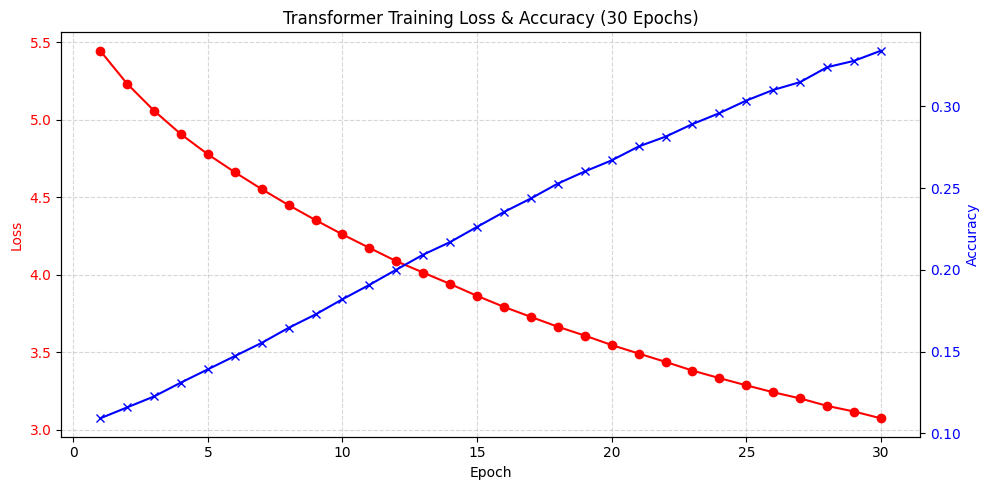

In [ ]:
import matplotlib.pyplot as plt
train_losses = [
    5.4451, 5.2321, 5.0584, 4.9066, 4.7771, 4.6616, 4.5524, 4.4494, 4.3529, 4.2605,
    4.1737, 4.0878, 4.0144, 3.9408, 3.8642, 3.7932, 3.7286, 3.6652, 3.6083, 3.5473,
    3.4923, 3.4387, 3.3825, 3.3340, 3.2874, 3.2428, 3.2031, 3.1549, 3.1187, 3.0746
]
train_accuracies = [
    0.1091, 0.1158, 0.1225, 0.1310, 0.1391, 0.1472, 0.1553, 0.1645, 0.1727, 0.1820,
    0.1908, 0.2001, 0.2093, 0.2170, 0.2263, 0.2354, 0.2437, 0.2528, 0.2602, 0.2670,
    0.2755, 0.2815, 0.2892, 0.2959, 0.3036, 0.3101, 0.3149, 0.3240, 0.3279, 0.3341
]
def plot_training_metrics(losses, accuracies):
    epochs = range(1, len(losses)+1)
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(epochs, losses, 'r-o', label='Train Loss')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color='r')
    ax1.tick_params(axis='y', labelcolor='r')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax2 = ax1.twinx()
    ax2.plot(epochs, accuracies, 'b-x', label='Train Accuracy')
    ax2.set_ylabel("Accuracy", color='b')
    ax2.tick_params(axis='y', labelcolor='b')


    plt.title("Transformer Training Loss & Accuracy (30 Epochs)")

    fig.tight_layout()
    plt.show()


plot_training_metrics(train_losses, train_accuracies)

In [ ]:
torch.save(model.state_dict(), "transformer_word_pred.pth")

In [ ]:
import torch
import torch.nn.functional as F

def generate_text_sampling(model, start_text, vocab, seq_len=10, gen_len=50, device="cpu", temperature=1.0):
    model.eval()
    idx_to_word = {v: k for k, v in vocab.items()}

    words = start_text.lower().split()
    generated = [vocab.get(w, vocab["<UNK>"]) for w in words]

    for _ in range(gen_len):
        x = torch.tensor([generated[-seq_len:]], dtype=torch.long).to(device)
        with torch.no_grad():
            y_pred = model(x)
            y_pred = y_pred.squeeze() / temperature
            probs = F.softmax(y_pred, dim=0)
            next_idx = torch.multinomial(probs, 1).item()

        generated.append(next_idx)

    generated_text = [idx_to_word[i] for i in generated]
    return " ".join(generated_text)

In [ ]:
start_text = "what the peoples thinks"
generated_text = generate_text_sampling(
    model,
    start_text=start_text,
    vocab=vocab,
    seq_len=50,
    gen_len=10,
    device=device,
    temperature=1.2
)

print("Generated Text:\n", generated_text)

Generated Text:
 what the peoples thinks majesty it let even it dispersed henry own when where
